<a href="https://colab.research.google.com/github/sibasishsahu68/AML-Lab/blob/main/Experiment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please enter the input data:
Enter X values (comma-separated, e.g., 2,3,4): 1,2,3
Enter y values (comma-separated, e.g., 3,4,5): 2,3,4
Enter number of iterations (e.g., 1000): 4

--- Running Ridge Regression ---
Ridge Weights: 0.8451551913580246
Ridge Bias: 0.39941754629629633


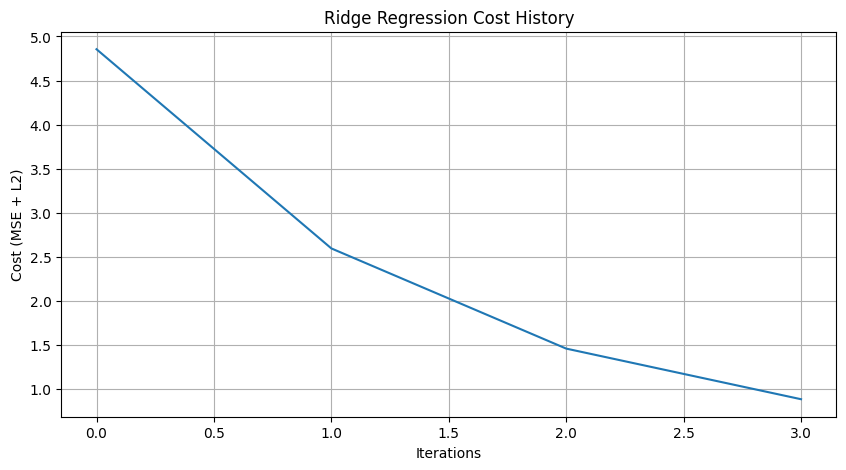

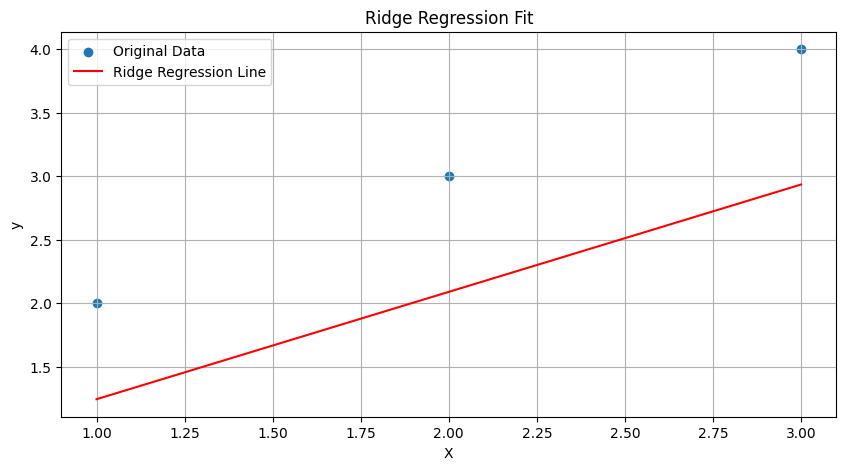


--- Running Lasso Regression ---
Lasso Weights: 0.8488121913580247
Lasso Bias: 0.39985532407407415


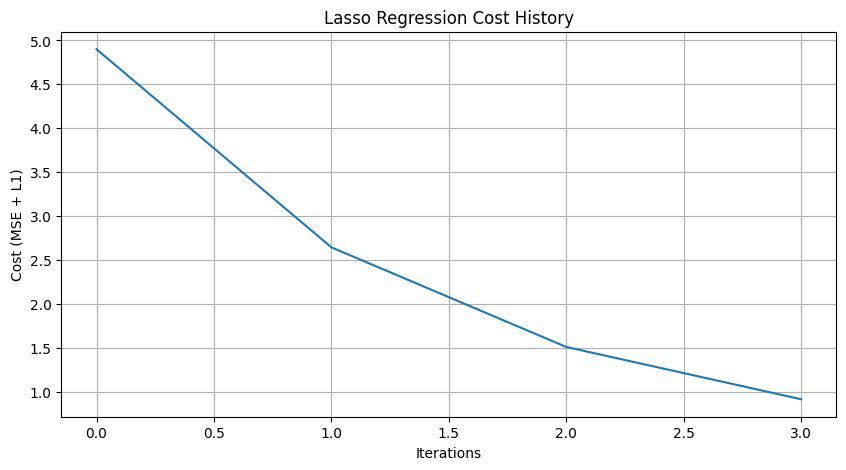

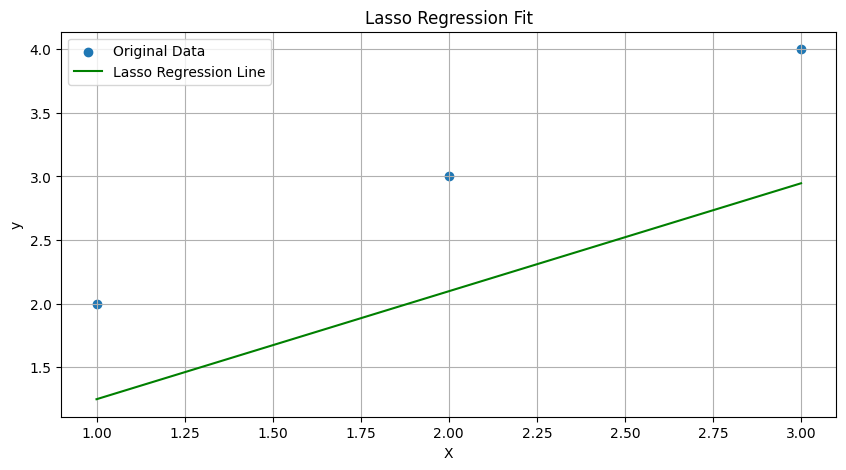

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def ridge_regression_gd(X, y, learning_rate, n_iterations, lambda_param):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    cost_history = []

    for i in range(n_iterations):
        y_predicted = np.dot(X, weights) + bias
        dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) + (2 * lambda_param * weights)
        db = (1 / n_samples) * np.sum(y_predicted - y)
        weights -= learning_rate * dw
        bias -= learning_rate * db
        cost = (1 / (2 * n_samples)) * np.sum((y_predicted - y)**2) + (lambda_param * np.sum(weights**2))
        cost_history.append(cost)

    return weights, bias, cost_history


def lasso_regression_gd(X, y, learning_rate, n_iterations, lambda_param):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    cost_history = []

    for i in range(n_iterations):
        y_predicted = np.dot(X, weights) + bias
        # Lasso uses L1 regularization, so the derivative of |weights| is sign(weights)
        # A small epsilon is added to avoid issues with derivative at 0
        dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) + lambda_param * np.sign(weights)
        db = (1 / n_samples) * np.sum(y_predicted - y)
        weights -= learning_rate * dw
        bias -= learning_rate * db
        cost = (1 / (2 * n_samples)) * np.sum((y_predicted - y)**2) + (lambda_param * np.sum(np.abs(weights)))
        cost_history.append(cost)

    return weights, bias, cost_history

# Define input data for both regressions
print("Please enter the input data:")
X_input = input("Enter X values (comma-separated, e.g., 2,3,4): ")
Y_input = input("Enter y values (comma-separated, e.g., 3,4,5): ")

X = np.array([float(x.strip()) for x in X_input.split(',')]).reshape(-1, 1)
y = np.array([float(y_val.strip()) for y_val in Y_input.split(',')])

learning_rate = ALPHA
n_iterations = int(input("Enter number of iterations (e.g., 1000): "))
# lambda_param is already defined globally

print("\n--- Running Ridge Regression ---")
weights_ridge, bias_ridge, cost_history_ridge = ridge_regression_gd(X, y, learning_rate, n_iterations, lambda_param)
print(f"Ridge Weights: {weights_ridge[0]}")
print(f"Ridge Bias: {bias_ridge}")

plt.figure(figsize=(10, 5))
plt.plot(range(n_iterations), cost_history_ridge)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE + L2)")
plt.title("Ridge Regression Cost History")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Original Data")
plt.plot(X, np.dot(X, weights_ridge) + bias_ridge, color='red', label="Ridge Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Ridge Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Running Lasso Regression ---")
weights_lasso, bias_lasso, cost_history_lasso = lasso_regression_gd(X, y, learning_rate, n_iterations, lambda_param)
print(f"Lasso Weights: {weights_lasso[0]}")
print(f"Lasso Bias: {bias_lasso}")

plt.figure(figsize=(10, 5))
plt.plot(range(n_iterations), cost_history_lasso)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE + L1)")
plt.title("Lasso Regression Cost History")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Original Data")
plt.plot(X, np.dot(X, weights_lasso) + bias_lasso, color='green', label="Lasso Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Lasso Regression Fit")
plt.legend()
plt.grid(True)
plt.show()